In [52]:
import os
import pandas as pd
import math
import matplotlib.pyplot as plt
import numpy as np
import seaborn
import time

from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split

In [53]:
STUDENT_ID = 42


In [54]:
df = pd.read_csv('glass.data', names=["Id", "RI","Na","Mg","Al","Si","K","Ca","Ba","Fe", "Class Type"])
target_names = ['building_windows_float_processed', "building_windows_non_float_processed", "vehicle_windows_float_processed", "vehicle_windows_non_float_processed", "containers", "tableware", "headlamps"]

Retrieve the dataset from the "glass.data" textfile.
Retrieve the category names for the dataset.

```df``` = Entire "glass" Dataset.

```target_names``` = All Categories of "glass" dataset.

In [55]:
X = df.drop(columns=["Id", "Class Type"])
y = df["Class Type"]

Define ```X``` and ```y``` as the data and corresponding category/class_type respectively.

In [56]:
# Split Data
x_temp, x_test, y_temp, y_test = train_test_split(X, y, test_size=0.2, random_state=STUDENT_ID, stratify=y)
x_train, x_validate, y_train, y_validate = train_test_split(x_temp, y_temp, test_size=0.25, random_state=STUDENT_ID, stratify=y_temp)  

Split the data into three sections.

```x_test``` ```y_test``` : Used to test the model.

```x_train``` ```y_train``` : Used to train the model.

```x_validate``` ```y_validate``` : Used to fine-tune the model.

# Custom KNN Implementation

In [57]:
# # Feature Scaling via standardisation
x_mean = x_train.mean()
x_std = x_train.std() + 0.000000001

x_train_scaled = ((x_train - x_mean) / x_std).to_numpy()
x_test_scaled = ((x_test - x_mean) / x_std).to_numpy()
x_validate_scaled = ((x_validate - x_mean) / x_std).to_numpy()

Feature scaling implemented via standardisation / z-score normalisation.

Uses the ```x_train``` dataframe to get a mean and standard diviation, replaces 0 with 1 in ```x_std``` and then standardises ```x_train```,```x_test```, and ```x_validate```

In [58]:
class knn_classifier:
    k = 1
    x_train_data = None
    y_train_data = None
    distance_list = []

    def __init__(self, init_k = -1):
        if (init_k >= 1):
            self.k = init_k
            return
    
    def fit(self, x, y):
        self.x_train_data = x
        self.y_train_data = y

    def euclidean_squared_distance(self, test_row):
        self.distance_list = []
        for i in range (len(self.x_train_data)):
            distance = 0.0
            
            train_row = self.x_train_data[i]

            for y in range(len(train_row)):
                distance += (test_row[y] - train_row[y]) ** 2

            self.distance_list.append((i, distance))
        self.distance_list.sort(key=lambda x: x[1])

    def manhattan_distance(self, test_row):
        self.distance_list = []
        for i in range (len(self.x_train_data)):
            distance = 0.0
            
            train_row = self.x_train_data[i]

            for y in range(len(train_row)):
                distance += abs((test_row[y] - train_row[y]))

            self.distance_list.append((i, math.sqrt(distance)))
        self.distance_list.sort(key=lambda x: x[1])

    def maximum_distance(self, test_row):
        self.distance_list = []
        for i in range (len(self.x_train_data)):
            distance = 0.0
            
            train_row = self.x_train_data[i]

            for y in range(len(train_row)):
                temp_distance = abs((test_row[y] - train_row[y]))
                if temp_distance > distance:
                    distance = temp_distance


            self.distance_list.append((train_row, math.sqrt(distance)))
        self.distance_list.sort(key=lambda x: x[1])

    
    def get_nearest_neighbors(self):
        neighbors_list = []
        for i in range (self.k):
            row_num = self.distance_list[i][0]
            y = self.y_train_data.iloc[row_num]
            neighbors_list.append(y)
        return neighbors_list

    def predict_classification(self, test_row):
        self.euclidean_squared_distance(test_row)
        neighbors = self.get_nearest_neighbors()
        prediction = max(neighbors, key=neighbors.count)
        return prediction


    def best_k(self, x, y):
        best_accuracy = 0
        best_k_value = None

        for newK in range(1, 11, 2): # Odds only
            self.k = newK
            predictions = []

            for x_item in x:
                prediction = self.predict_classification(x_item)
                predictions.append(prediction)
                npPredictions = np.array(predictions)
            accuracy = np.mean(npPredictions == y.values) * 100
            if accuracy > best_accuracy:
                best_accuracy = accuracy
                best_k_value = newK
        self.k = best_k_value

In [59]:
knn_model = knn_classifier()
knn_model.fit(x_train_scaled, y_train)
knn_model.best_k(x_validate_scaled, y_validate)

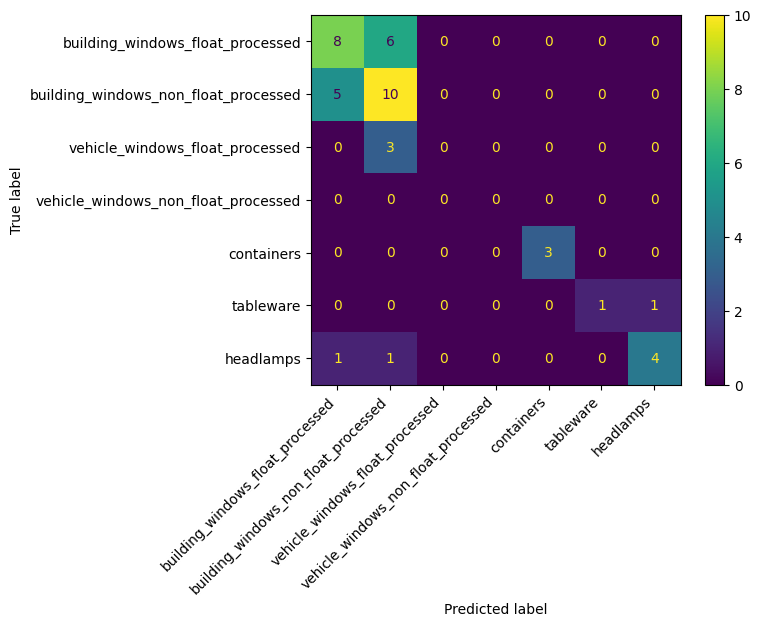

For K=7, Accuracy is 60.46511627906976


In [60]:
test_predictions = []
test_actual = []

def testKNN():
    for i in range(len(x_test_scaled)):
        prediction = knn_model.predict_classification(x_test_scaled[i])
        test_predictions.append(prediction)
        test_actual.append(y_test.iloc[i])

    cm = confusion_matrix(y_true=test_actual, y_pred=test_predictions, labels=[1,2,3,4,5,6,7])

    cm_display = ConfusionMatrixDisplay(confusion_matrix = cm, display_labels=target_names)

    cm_display.plot()

    plt.setp(cm_display.ax_.get_xticklabels(), rotation=45, ha="right")
    plt.show() 

    accuracy = np.mean(np.array(test_predictions) == y_test) * 100
    print(f'For K={knn_model.k}, Accuracy is {accuracy}')
testKNN()

# Custom Decision Trees Implementation

In [61]:
from collections import Counter
class Node:
    def __init__(self, feature=None, threshold=None, left=None, right=None, value=None):
        self.feature = feature
        self.threshold = threshold
        self.left = left
        self.right = right

        # Leaf Node Value
        self.value = value

In [62]:
class decisionTreeClassifier:

    def __init__(self, max_depth = 6, min_samples_split = 2):
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split

    # Store the training data
    def fit(self, x, y):
        self.x_train_data = x
        self.y_train_data = y
        self.rootNode = self.build_tree(x, y)

    # Calculate the Gini impurity for a given set of labels.
    def gini_impurity(self, y):
        probability = (np.bincount(y) / len(y))
        gini = 1 - (np.sum(probability ** 2))
        return gini
    
    # Calculate the weighted average Gini impurity for a split given the left and right splits.
    def gini_weight_average(self, y, y_left, y_right):
        average = (len(y_left) * self.gini_impurity(y_left) + len(y_right) * self.gini_impurity(y_right)) / len(y)
        return average

    def split(self, x, y, feature, threshold):
        mask = x[:, feature] <= threshold

        x_left = x[mask]
        y_left = y[mask]
        x_right = x[~mask]
        y_right = y[~mask]

        return x_left, y_left, x_right, y_right

    def build_tree(self, x, y, current_depth=0):
        
        best_gini = 1000000
        best_threshold = None
        best_feature = None

        n_samples, n_features = x.shape

        if current_depth == self.max_depth or n_samples < self.min_samples_split or len(np.unique(y)) == 1:
            node = Node(feature=best_feature, threshold=best_threshold, value=Counter(y).most_common(1)[0][0])
            return node

        for i in range(n_features):
            for threshold in np.unique(x[:, i]):
                mask = x[:, i] <= threshold

                y_left = y[mask]
                y_right = y[~mask]
                gini_avg = self.gini_weight_average(y, y_left, y_right)

                if gini_avg < best_gini:
                    best_gini = gini_avg
                    best_threshold = threshold
                    best_feature = i

        x_first_split, y_first_split, x_second_split, y_second_split = self.split(x, y, best_feature, best_threshold)


        if len(y_first_split) == 0 or len(y_second_split) == 0:
            return Node(feature = best_feature, threshold = best_threshold, value=Counter(y).most_common(1)[0][0])

        left_subtree = self.build_tree(x_first_split, y_first_split, current_depth + 1)
        right_subtree = self.build_tree(x_second_split, y_second_split, current_depth + 1)
        
        node = Node(feature=best_feature, threshold=best_threshold, left=left_subtree, right=right_subtree)

        return node

    def predict(self, x, node):
        if node.left is None and node.right is None:
            return node.value
        
        if x[node.feature] <= node.threshold:
            return self.predict(x, node.left)
        
        return self.predict(x, node.right)

    def predict_classification(self, x):
            predictions = []
            for row in x:
                prediction = self.predict(row, self.rootNode)
                predictions.append(prediction)
            return predictions

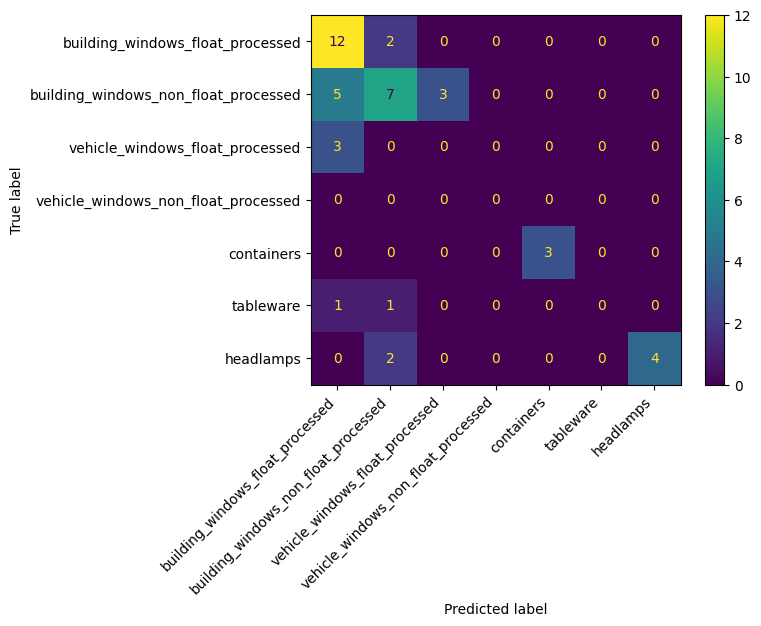

In [63]:
x_train_np = x_train.to_numpy()
y_train_np = y_train.to_numpy()

x_test_np = x_test.to_numpy()
y_test_np = y_test.to_numpy()

decisionTreeModel = decisionTreeClassifier()
decisionTreeModel.fit(x_train_np, y_train_np)

test_predictions = decisionTreeModel.predict_classification(x_test_np)

cm = confusion_matrix(y_true=y_test_np, y_pred=test_predictions, labels=[1,2,3,4,5,6,7])
cm_display = ConfusionMatrixDisplay(confusion_matrix = cm, display_labels=target_names)
cm_display.plot()
plt.setp(cm_display.ax_.get_xticklabels(), rotation=45, ha="right")
plt.show()

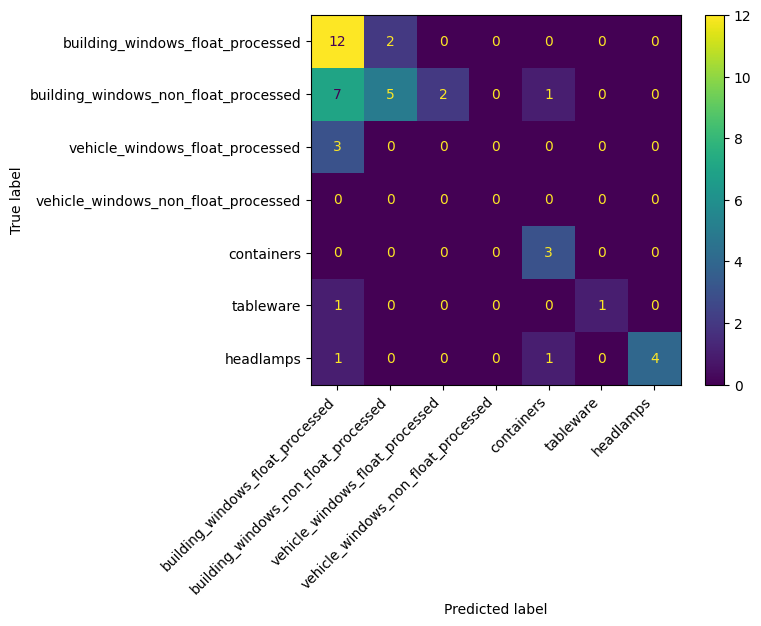

Sklearn Decision Tree (criterion='gini')
Validation Accuracy: 69.77%
Test Accuracy: 58.14%


In [64]:
from sklearn.tree import DecisionTreeClassifier

# Sklearn baseline decision tree (Gini) for comparison with custom implementation
sk_dt = DecisionTreeClassifier(criterion="gini", random_state=STUDENT_ID, max_depth=6)
sk_dt.fit(x_train, y_train)

y_val_pred = sk_dt.predict(x_validate)
val_acc = np.mean(y_val_pred == y_validate) * 100

y_test_pred = sk_dt.predict(x_test)
test_acc = np.mean(y_test_pred == y_test) * 100

cm = confusion_matrix(y_true=y_test, y_pred=y_test_pred, labels=[1, 2, 3, 4, 5, 6, 7])
cm_display = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=target_names)
cm_display.plot()
plt.setp(cm_display.ax_.get_xticklabels(), rotation=45, ha="right")
plt.show()

print(f"Sklearn Decision Tree (criterion='gini')")
print(f"Validation Accuracy: {val_acc:.2f}%")
print(f"Test Accuracy: {test_acc:.2f}%")